# TP : Mini Réseau de Neurones avec NumPy et Matplotlib

 activations, forward propagation, backpropagation, entraînement, métriques, ROC/AUC et étude d'influence.

In [1]:
# ============================================================
# TP : Mini Réseau de Neurones avec NumPy et Matplotlib
# Objectif : Implémentation from scratch d'un MLP 2 -> H -> 1
# Dataset : XOR + XOR bruité
# Auteur : Amal Chebri


In [2]:
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Pour rendre les résultats reproductibles
np.random.seed(0)




In [3]:
# ============================================================
# 1. Fonctions d'activation + dérivées


In [4]:
# ============================================================

def relu(z):
    return np.maximum(0, z)

def d_relu(z=None, out=None):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_stable(z):
    """
    Version stable de sigmoid pour éviter overflow/underflow.
    """
    z = np.asarray(z)
    return np.where(
        z >= 0,
        1 / (1 + np.exp(-z)),
        np.exp(z) / (1 + np.exp(z))
    )

def d_sigmoid(z=None, out=None):
    """
    Dérivée de sigmoid. On utilise out = sigmoid(z).
    """
    if out is None:
        out = sigmoid_stable(z)
    return out * (1 - out)

def tanh(z):
    return np.tanh(z)

def d_tanh(z=None, out=None):
    """
    Dérivée de tanh. On utilise out = tanh(z).
    """
    if out is None:
        out = np.tanh(z)
    return 1 - out**2

def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)

def d_leaky_relu(z=None, out=None, alpha=0.1):
    return np.where(z > 0, 1.0, alpha)

def softplus(z):
    """
    Softplus stable : log(1 + exp(z))
    """
    return np.log1p(np.exp(-np.abs(z))) + np.maximum(z, 0)

def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

def d_elu(z=None, out=None, alpha=1.0):
    return np.where(z > 0, 1.0, alpha * np.exp(z))


activations = {
    "ReLU": relu,
    "Sigmoid": sigmoid,
    "Sigmoid_stable": sigmoid_stable,
    "Tanh": tanh,
    "LeakyReLU": leaky_relu,
    "Softplus": softplus,
    "ELU": elu
}

d_activations = {
    "ReLU": d_relu,
    "Sigmoid": d_sigmoid,
    "Sigmoid_stable": d_sigmoid,
    "Tanh": d_tanh,
    "LeakyReLU": d_leaky_relu,
    "ELU": d_elu
}




In [5]:
# ============================================================
# 2. Visualisation des fonctions d'activation


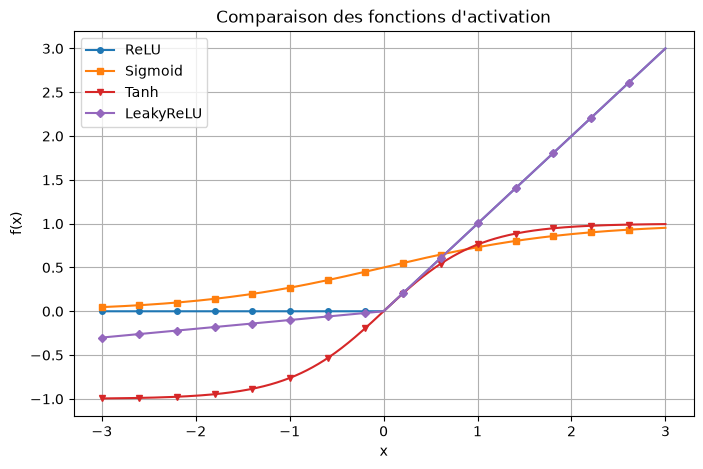

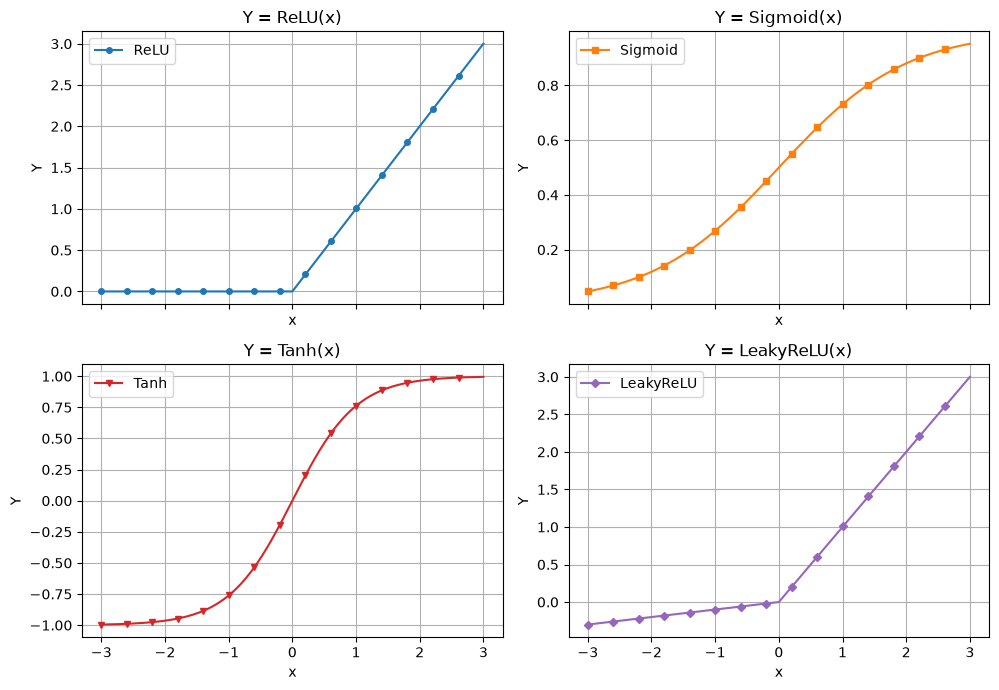

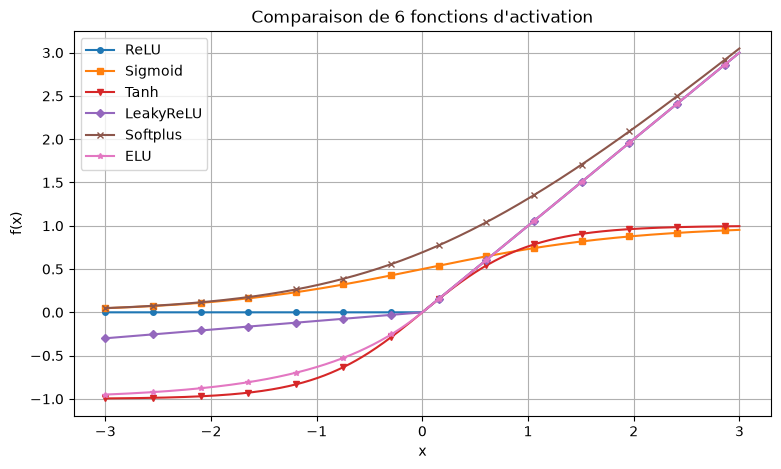

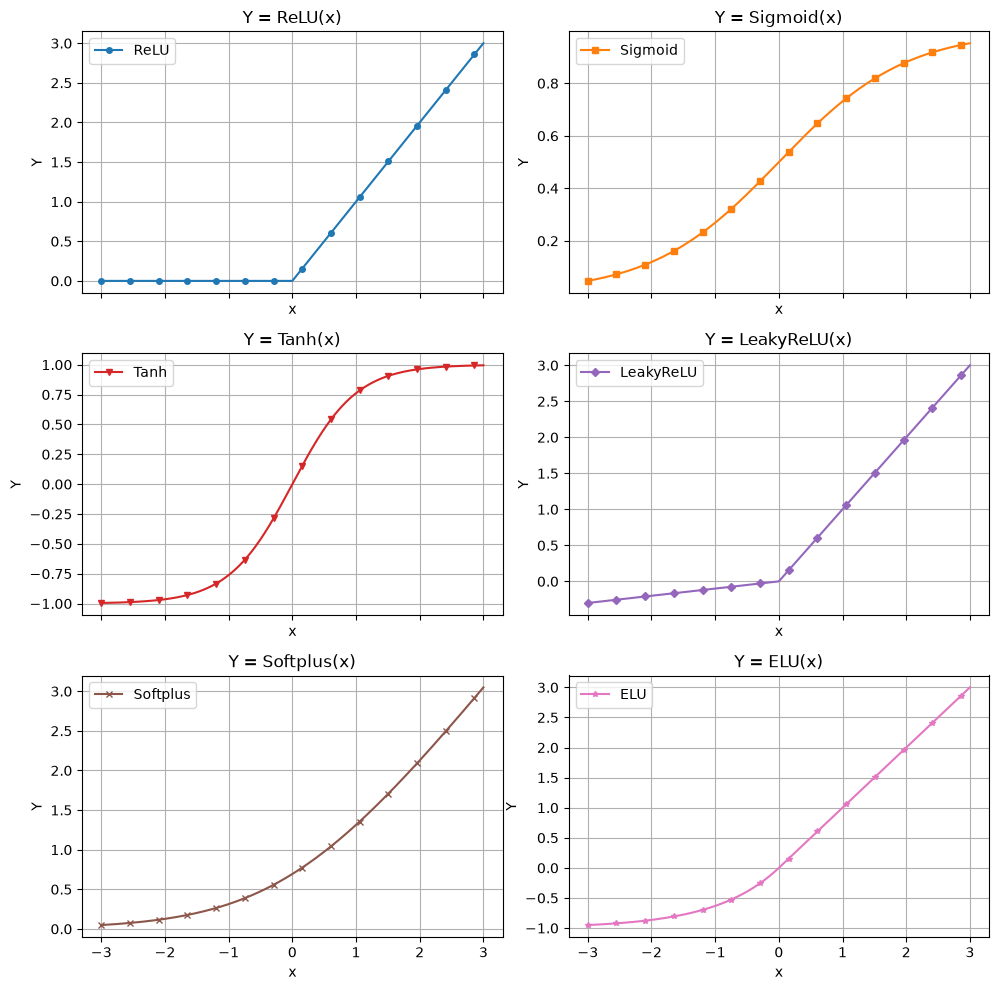

In [6]:
# ============================================================

x_plot = np.linspace(-3, 3, 600)

couleurs = {
    "ReLU": "tab:blue",
    "Sigmoid": "tab:orange",
    "Sigmoid_stable": "tab:green",
    "Tanh": "tab:red",
    "LeakyReLU": "tab:purple",
    "Softplus": "tab:brown",
    "ELU": "tab:pink"
}

markers = {
    "ReLU": "o",
    "Sigmoid": "s",
    "Sigmoid_stable": "^",
    "Tanh": "v",
    "LeakyReLU": "D",
    "Softplus": "x",
    "ELU": "*"
}

# 2.1 Tracé comparatif sur une seule figure : 4 activations demandées
plt.figure(figsize=(8, 5))
for name in ["ReLU", "Sigmoid", "Tanh", "LeakyReLU"]:
    plt.plot(
        x_plot,
        activations[name](x_plot),
        label=name,
        color=couleurs[name],
        marker=markers[name],
        markersize=4,
        markevery=40
    )

plt.title("Comparaison des fonctions d'activation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

# 2.2 Grille 2x2 : une fonction par sous-figure
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.ravel()

for ax, name in zip(axes, ["ReLU", "Sigmoid", "Tanh", "LeakyReLU"]):
    ax.plot(
        x_plot,
        activations[name](x_plot),
        label=name,
        color=couleurs[name],
        marker=markers[name],
        markersize=4,
        markevery=40
    )
    ax.set_title(f"Y = {name}(x)")
    ax.set_xlabel("x")
    ax.set_ylabel("Y")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# 2.3 Extension : tracé comparatif avec 6 fonctions
plt.figure(figsize=(9, 5))
for name in ["ReLU", "Sigmoid", "Tanh", "LeakyReLU", "Softplus", "ELU"]:
    plt.plot(
        x_plot,
        activations[name](x_plot),
        label=name,
        color=couleurs[name],
        marker=markers[name],
        markersize=4,
        markevery=45
    )

plt.title("Comparaison de 6 fonctions d'activation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

# 2.4 Extension : subplots 3x2 pour 6 fonctions
def sub_tracer(rows=3, cols=2):
    names = ["ReLU", "Sigmoid", "Tanh", "LeakyReLU", "Softplus", "ELU"]
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10), sharex=True)
    axes = axes.ravel()

    for ax, name in zip(axes, names):
        ax.plot(
            x_plot,
            activations[name](x_plot),
            label=name,
            color=couleurs[name],
            marker=markers[name],
            markersize=4,
            markevery=45
        )
        ax.set_title(f"Y = {name}(x)")
        ax.set_xlabel("x")
        ax.set_ylabel("Y")
        ax.grid(True)
        ax.legend()

    # cacher les axes inutilisés si rows*cols > nombre de fonctions
    for i in range(len(names), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

sub_tracer(3, 2)




In [7]:
# ============================================================
# 3. Dataset XOR simple


Shape X : (4, 2)
Shape y : (4, 1)


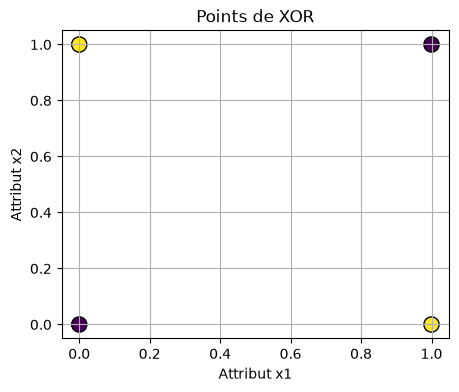

In [8]:
# ============================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

# Visualisation des points XOR
plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=120, edgecolor="black")
plt.title("Points de XOR")
plt.xlabel("Attribut x1")
plt.ylabel("Attribut x2")
plt.grid(True)
plt.show()




In [9]:
# ============================================================
# 4. Initialisation des paramètres du réseau 2 -> H -> 1


In [10]:
# ============================================================

def init_params(input_dim=2, hidden_dim=3, output_dim=1, seed=0):
    """
    Initialisation des poids et biais.
    Les poids sont petits pour aider l'entraînement.
    """
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 0.5, size=(input_dim, hidden_dim))
    b1 = np.zeros((1, hidden_dim))
    W2 = rng.normal(0, 0.5, size=(hidden_dim, output_dim))
    b2 = np.zeros((1, output_dim))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params(hidden_dim=3, seed=0)

print("W1.shape :", W1.shape)
print("b1.shape :", b1.shape)
print("W2.shape :", W2.shape)
print("b2.shape :", b2.shape)




W1.shape : (2, 3)
b1.shape : (1, 3)
W2.shape : (3, 1)
b2.shape : (1, 1)


In [11]:
# ============================================================
# 5. Forward Propagation


In [12]:
# ============================================================

def forward(X, W1, b1, W2, b2, act_hid_name="Tanh", act_out_name="Sigmoid_stable"):
    """
    Propagation avant :
    Z1 = XW1 + b1
    A1 = activation_hidden(Z1)
    Z2 = A1W2 + b2
    y_hat = sigmoid(Z2)
    """
    act_hid = activations[act_hid_name]
    act_out = activations[act_out_name]

    Z1 = X @ W1 + b1
    A1 = act_hid(Z1)
    Z2 = A1 @ W2 + b2
    y_hat = act_out(Z2)

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "y_hat": y_hat,
        "act_hid_name": act_hid_name,
        "act_out_name": act_out_name
    }

    return y_hat, cache




In [13]:
# ============================================================
# 6. Fonction de perte MSE


In [14]:
# ============================================================

def mse(y_hat, y):
    return np.mean((y_hat - y) ** 2)




In [15]:
# ============================================================
# 7. Backpropagation


In [16]:
# ============================================================

def backward(y, cache, W2):
    """
    Calcul des gradients avec MSE + sigmoid en sortie.
    Compatible avec Tanh, ReLU, LeakyReLU et ELU pour la couche cachée.
    """
    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    y_hat = cache["y_hat"]
    act_hid_name = cache["act_hid_name"]

    N = y.shape[0]

    # dL/dy_hat pour MSE
    dY = 2 * (y_hat - y) / N

    # sortie sigmoid
    dZ2 = dY * d_sigmoid(out=y_hat)

    # gradients W2, b2
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # propagation vers couche cachée
    dA1 = dZ2 @ W2.T

    # dérivée activation cachée
    if act_hid_name == "Tanh":
        dZ1 = dA1 * d_tanh(out=A1)
    elif act_hid_name == "ReLU":
        dZ1 = dA1 * d_relu(z=Z1)
    elif act_hid_name == "LeakyReLU":
        dZ1 = dA1 * d_leaky_relu(z=Z1)
    elif act_hid_name == "ELU":
        dZ1 = dA1 * d_elu(z=Z1)
    else:
        raise ValueError("Activation cachée non supportée pour backprop : " + act_hid_name)

    # gradients W1, b1
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradients




In [17]:
# ============================================================
# 8. Entraînement du modèle


epoch=    0 loss=0.252173
epoch=  400 loss=0.009484
epoch=  800 loss=0.002013
epoch= 1200 loss=0.001073
epoch= 1600 loss=0.000723
epoch= 2000 loss=0.000543
epoch= 2400 loss=0.000433
epoch= 2800 loss=0.000360
epoch= 3200 loss=0.000308
epoch= 3600 loss=0.000268
Probabilités :
[[0.00601059]
 [0.98338094]
 [0.98362066]
 [0.01925501]]
Classes prédites :
[[0]
 [1]
 [1]
 [0]]


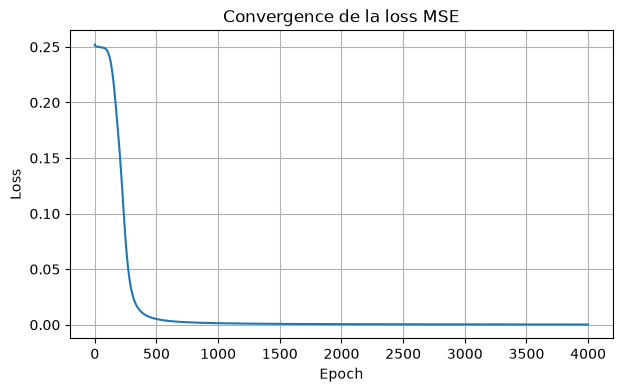

In [18]:
# ============================================================

def train(
    X,
    y,
    hidden_dim=3,
    lr=0.8,
    epochs=4000,
    act_hid_name="Tanh",
    act_out_name="Sigmoid_stable",
    seed=0,
    verbose=True
):
    """
    Entraînement par descente de gradient.
    """
    W1, b1, W2, b2 = init_params(
        input_dim=X.shape[1],
        hidden_dim=hidden_dim,
        output_dim=1,
        seed=seed
    )

    losses = []

    for epoch in range(epochs):
        # Forward
        y_hat, cache = forward(X, W1, b1, W2, b2, act_hid_name, act_out_name)

        # Loss
        L = mse(y_hat, y)
        losses.append(L)

        # Backpropagation
        grads = backward(y, cache, W2)

        # Mise à jour
        W1 -= lr * grads["dW1"]
        b1 -= lr * grads["db1"]
        W2 -= lr * grads["dW2"]
        b2 -= lr * grads["db2"]

        if verbose and epoch % max(1, epochs // 10) == 0:
            print(f"epoch={epoch:5d} loss={L:.6f}")

    return W1, b1, W2, b2, losses


# Test sur XOR simple
W1t, b1t, W2t, b2t, losses = train(
    X, y,
    hidden_dim=3,
    lr=0.8,
    epochs=4000,
    act_hid_name="Tanh",
    seed=0,
    verbose=True
)

y_pred_prob, _ = forward(X, W1t, b1t, W2t, b2t, "Tanh", "Sigmoid_stable")
y_pred_class = (y_pred_prob >= 0.5).astype(int)

print("Probabilités :")
print(y_pred_prob)
print("Classes prédites :")
print(y_pred_class)

# Courbe de convergence
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("Convergence de la loss MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()




In [19]:
# ============================================================
# 9. Dataset XOR bruité


X_noisy shape : (400, 2)
y_noisy shape : (400, 1)


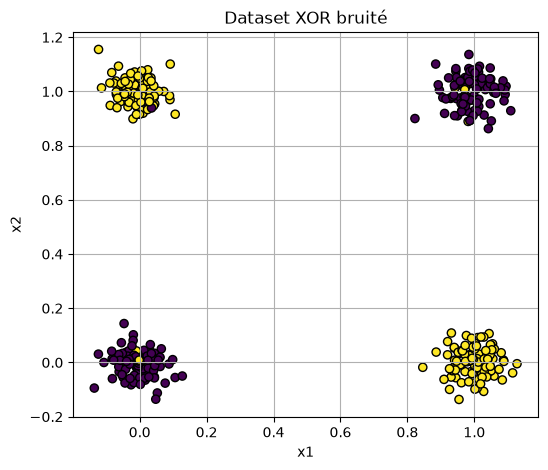

In [20]:
# ============================================================

def make_noisy_xor(n=100, noise=0.05, flip=0.04, seed=0):
    """
    Génère un dataset XOR bruité.
    - n : nombre d'exemples par coin XOR
    - noise : écart-type du bruit gaussien
    - flip : probabilité d'inverser un label
    """
    rng = np.random.default_rng(seed)

    coins = np.array([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ], dtype=float)

    labels = np.array([
        [0],
        [1],
        [1],
        [0]
    ], dtype=float)

    Xn = np.repeat(coins, n, axis=0)
    yn = np.repeat(labels, n, axis=0)

    # Ajout du bruit gaussien
    Xn += rng.normal(0, noise, Xn.shape)

    # Inversion aléatoire de certains labels
    mask = rng.random(len(yn)) < flip
    yn[mask] = 1 - yn[mask]

    return Xn, yn


X_noisy, y_noisy = make_noisy_xor(n=100, noise=0.05, flip=0.04, seed=1)

print("X_noisy shape :", X_noisy.shape)
print("y_noisy shape :", y_noisy.shape)

# Visualisation dataset bruité
plt.figure(figsize=(6, 5))
plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_noisy.ravel(), s=35, edgecolor="black")
plt.title("Dataset XOR bruité")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()




In [21]:
# ============================================================
# 10. Split Train / Test


In [22]:
# ============================================================

def split_dataset(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    N = len(X)
    indices = np.arange(N)
    rng.shuffle(indices)

    cut = int((1 - test_ratio) * N)
    train_idx = indices[:cut]
    test_idx = indices[cut:]

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_dataset(X_noisy, y_noisy, test_ratio=0.2, seed=0)

print("Train size :", X_train.shape)
print("Test size  :", X_test.shape)




Train size : (320, 2)
Test size  : (80, 2)


In [23]:
# ============================================================
# 11. Entraînement sur dataset bruité


In [24]:
# ============================================================

W1n, b1n, W2n, b2n, losses_noisy = train(
    X_train,
    y_train,
    hidden_dim=6,
    lr=0.5,
    epochs=20000,
    act_hid_name="Tanh",
    seed=2,
    verbose=True
)

y_score, _ = forward(X_test, W1n, b1n, W2n, b2n, "Tanh", "Sigmoid_stable")
threshold = 0.5
y_pred_test = (y_score >= threshold).astype(int)

print("Premières probabilités :")
print(y_score[:5])
print("Premières classes :")
print(y_pred_test[:5])




epoch=    0 loss=0.243091
epoch= 2000 loss=0.027326
epoch= 4000 loss=0.027138
epoch= 6000 loss=0.027094
epoch= 8000 loss=0.027073
epoch=10000 loss=0.027060
epoch=12000 loss=0.027051
epoch=14000 loss=0.027044
epoch=16000 loss=0.027039
epoch=18000 loss=0.027034
Premières probabilités :
[[0.0338452 ]
 [0.99312255]
 [0.05159991]
 [0.97720139]
 [0.97697476]]
Premières classes :
[[0]
 [1]
 [0]
 [1]
 [1]]


In [25]:
# ============================================================
# 12. Matrice de confusion + métriques


TP : 34
TN : 42
FP : 1
FN : 3
Accuracy  : 0.9499999999999882
Precision : 0.9714285714285437
Recall    : 0.918918918918894
F1-score  : 0.9444444444439185


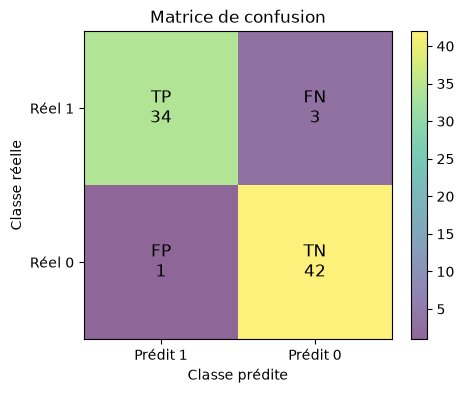

In [26]:
# ============================================================

def confusion_matrix_manual(y_true, y_pred):
    y_true = y_true.astype(int).ravel()
    y_pred = y_pred.astype(int).ravel()

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return TP, TN, FP, FN


def classification_metrics(TP, TN, FP, FN):
    eps = 1e-12
    accuracy = (TP + TN) / (TP + TN + FP + FN + eps)
    precision = TP / (TP + FP + eps)
    recall = TP / (TP + FN + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return accuracy, precision, recall, f1


TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred_test)
accuracy, precision, recall, f1 = classification_metrics(TP, TN, FP, FN)

print("TP :", TP)
print("TN :", TN)
print("FP :", FP)
print("FN :", FN)
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-score  :", f1)

# Affichage matrice de confusion
cm = np.array([[TP, FN],
               [FP, TN]])

cm_txt = np.array([[f"TP\n{TP}", f"FN\n{FN}"],
                   [f"FP\n{FP}", f"TN\n{TN}"]])

plt.figure(figsize=(5, 4))
plt.imshow(cm, alpha=0.6)
plt.title("Matrice de confusion")
plt.colorbar()

plt.xticks([0, 1], ["Prédit 1", "Prédit 0"])
plt.yticks([0, 1], ["Réel 1", "Réel 0"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm_txt[i, j], ha="center", va="center", fontsize=12)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()




In [27]:
# ============================================================
# 13. Courbe ROC + AUC


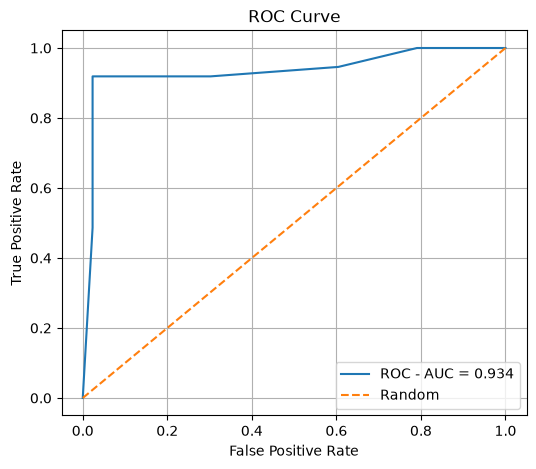

AUC = 0.9343180389691546


In [28]:
# ============================================================

def roc_curve_manual(y_true, y_score):
    thresholds = np.linspace(1, 0, 200)
    TPR = []
    FPR = []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred)

        tpr = TP / (TP + FN + 1e-12)
        fpr = FP / (FP + TN + 1e-12)

        TPR.append(tpr)
        FPR.append(fpr)

    return np.array(FPR), np.array(TPR)


FPR, TPR = roc_curve_manual(y_test, y_score)
auc = np.trapezoid(TPR, FPR)

plt.figure(figsize=(6, 5))
plt.plot(FPR, TPR, label=f"ROC - AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

print("AUC =", auc)




In [29]:
# ============================================================
# 14. Etude d'influence du taux d'apprentissage


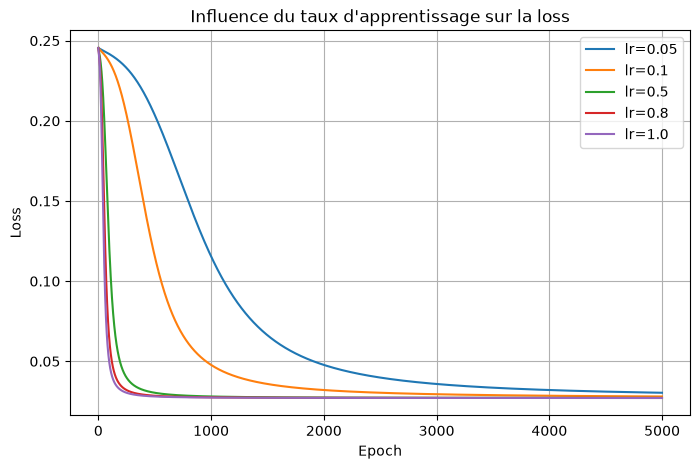

Résultats learning rate :
lr=0.05 | loss=0.0304 | accuracy=0.9500 | F1=0.9444
lr=0.1 | loss=0.0281 | accuracy=0.9500 | F1=0.9444
lr=0.5 | loss=0.0272 | accuracy=0.9500 | F1=0.9444
lr=0.8 | loss=0.0271 | accuracy=0.9500 | F1=0.9444
lr=1.0 | loss=0.0271 | accuracy=0.9500 | F1=0.9444


In [30]:
# ============================================================

learning_rates = [0.05, 0.1, 0.5, 0.8, 1.0]
results_lr = []

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    W1_lr, b1_lr, W2_lr, b2_lr, losses_lr = train(
        X_train,
        y_train,
        hidden_dim=6,
        lr=lr,
        epochs=5000,
        act_hid_name="Tanh",
        seed=3,
        verbose=False
    )

    y_score_lr, _ = forward(X_test, W1_lr, b1_lr, W2_lr, b2_lr, "Tanh", "Sigmoid_stable")
    y_pred_lr = (y_score_lr >= 0.5).astype(int)

    TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred_lr)
    acc, prec, rec, f1_lr = classification_metrics(TP, TN, FP, FN)

    results_lr.append([lr, losses_lr[-1], acc, f1_lr])
    plt.plot(losses_lr, label=f"lr={lr}")

plt.title("Influence du taux d'apprentissage sur la loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

print("Résultats learning rate :")
for row in results_lr:
    print(f"lr={row[0]} | loss={row[1]:.4f} | accuracy={row[2]:.4f} | F1={row[3]:.4f}")




In [31]:
# ============================================================
# 15. Etude d'influence du nombre de neurones cachés


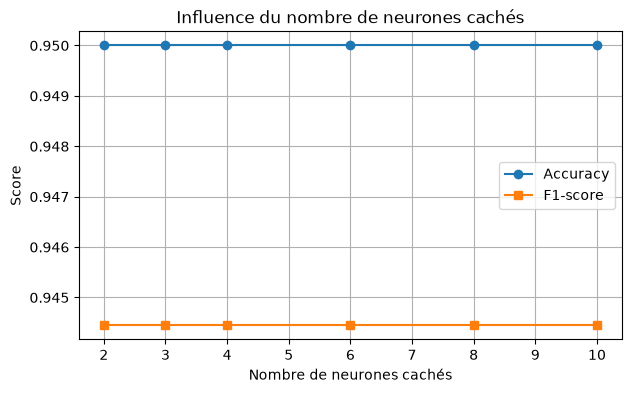

Résultats hidden_dim :
hidden_dim=2 | accuracy=0.9500 | F1=0.9444 | loss=0.0271
hidden_dim=3 | accuracy=0.9500 | F1=0.9444 | loss=0.0272
hidden_dim=4 | accuracy=0.9500 | F1=0.9444 | loss=0.0270
hidden_dim=6 | accuracy=0.9500 | F1=0.9444 | loss=0.0271
hidden_dim=8 | accuracy=0.9500 | F1=0.9444 | loss=0.0270
hidden_dim=10 | accuracy=0.9500 | F1=0.9444 | loss=0.0271


In [32]:
# ============================================================

hidden_dims = [2, 3, 4, 6, 8, 10]
results_hidden = []

for h in hidden_dims:
    W1_h, b1_h, W2_h, b2_h, losses_h = train(
        X_train,
        y_train,
        hidden_dim=h,
        lr=0.5,
        epochs=10000,
        act_hid_name="Tanh",
        seed=4,
        verbose=False
    )

    y_score_h, _ = forward(X_test, W1_h, b1_h, W2_h, b2_h, "Tanh", "Sigmoid_stable")
    y_pred_h = (y_score_h >= 0.5).astype(int)

    TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred_h)
    acc, prec, rec, f1_h = classification_metrics(TP, TN, FP, FN)

    results_hidden.append([h, acc, f1_h, losses_h[-1]])

results_hidden = np.array(results_hidden)

plt.figure(figsize=(7, 4))
plt.plot(results_hidden[:, 0], results_hidden[:, 1], marker="o", label="Accuracy")
plt.plot(results_hidden[:, 0], results_hidden[:, 2], marker="s", label="F1-score")
plt.title("Influence du nombre de neurones cachés")
plt.xlabel("Nombre de neurones cachés")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()

print("Résultats hidden_dim :")
for row in results_hidden:
    print(f"hidden_dim={int(row[0])} | accuracy={row[1]:.4f} | F1={row[2]:.4f} | loss={row[3]:.4f}")




In [33]:
# ============================================================
# 16. Etude d'influence de la fonction d'activation cachée


Résultats activation cachée :
activation=Tanh | accuracy=0.9500 | F1=0.9444 | loss=0.0271
activation=ReLU | accuracy=0.9500 | F1=0.9444 | loss=0.0270
activation=LeakyReLU | accuracy=0.9500 | F1=0.9444 | loss=0.0270
activation=ELU | accuracy=0.9500 | F1=0.9444 | loss=0.0271


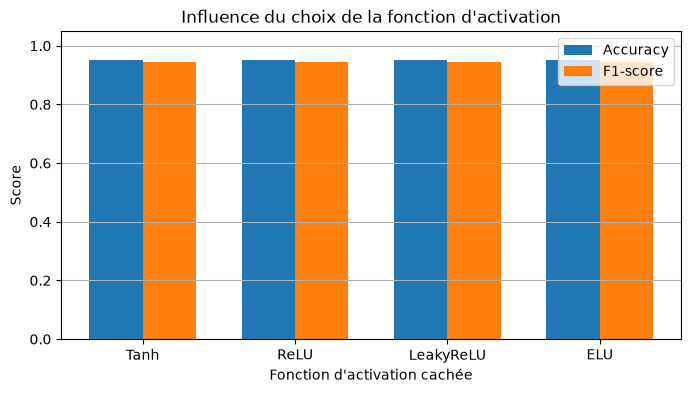

In [34]:
# ============================================================

hidden_activations = ["Tanh", "ReLU", "LeakyReLU", "ELU"]
results_act = []

for act_name in hidden_activations:
    W1_a, b1_a, W2_a, b2_a, losses_a = train(
        X_train,
        y_train,
        hidden_dim=6,
        lr=0.5,
        epochs=10000,
        act_hid_name=act_name,
        seed=5,
        verbose=False
    )

    y_score_a, _ = forward(X_test, W1_a, b1_a, W2_a, b2_a, act_name, "Sigmoid_stable")
    y_pred_a = (y_score_a >= 0.5).astype(int)

    TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred_a)
    acc, prec, rec, f1_a = classification_metrics(TP, TN, FP, FN)

    results_act.append([act_name, acc, f1_a, losses_a[-1]])

print("Résultats activation cachée :")
for row in results_act:
    print(f"activation={row[0]} | accuracy={row[1]:.4f} | F1={row[2]:.4f} | loss={row[3]:.4f}")

# Bar chart
names = [r[0] for r in results_act]
accs = [r[1] for r in results_act]
f1s = [r[2] for r in results_act]

x_pos = np.arange(len(names))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x_pos - width/2, accs, width, label="Accuracy")
plt.bar(x_pos + width/2, f1s, width, label="F1-score")
plt.xticks(x_pos, names)
plt.ylim(0, 1.05)
plt.title("Influence du choix de la fonction d'activation")
plt.xlabel("Fonction d'activation cachée")
plt.ylabel("Score")
plt.grid(True, axis="y")
plt.legend()
plt.show()




In [35]:
# ============================================================
# 17. Conclusion automatique


In [36]:
# ============================================================

print("\nConclusion :")
print("- Le réseau 2 -> H -> 1 apprend le problème XOR grâce à la couche cachée non linéaire.")
print("- Un learning rate trop petit ralentit l'apprentissage.")
print("- Un learning rate trop grand peut rendre l'entraînement instable.")
print("- Augmenter le nombre de neurones cachés améliore souvent la capacité du modèle, mais peut augmenter le risque de surapprentissage.")
print("- Tanh et LeakyReLU donnent généralement de bons résultats sur XOR.")



Conclusion :
- Le réseau 2 -> H -> 1 apprend le problème XOR grâce à la couche cachée non linéaire.
- Un learning rate trop petit ralentit l'apprentissage.
- Un learning rate trop grand peut rendre l'entraînement instable.
- Augmenter le nombre de neurones cachés améliore souvent la capacité du modèle, mais peut augmenter le risque de surapprentissage.
- Tanh et LeakyReLU donnent généralement de bons résultats sur XOR.
